<a href="https://colab.research.google.com/github/PereyraHebe/ISPC-Procesamiento-Habla-2026/blob/main/TP1_Eje1___Suarez_Mariela_Pereyra_Hebe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARTE 2: APLICACIÓN PRÁCTICA CON PYTHON (60 puntos)
Configuración Inicial


In [4]:
# 📥 Instalación de librerías (ejecutar una vez)
!pip install librosa numpy matplotlib scipy pandas seaborn
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy.signal import find_peaks
from IPython.display import Audio, display
# ⚙️Configuración
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42) # Para reproducibilidad
print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


Ejercicio 2.1: Generación y Análisis de Señales Sintéticas (15 puntos)
Consigna: Generarás tres señales diferentes para estudiar los efectos del muestreo
y cuantización.


1) fs1 = 2500 Hz | Nyquist: 1250.0 Hz | Aliasing: NO (porque 1000 Hz es menor a 1250.0 Hz)
   Error RMS: 0.3538


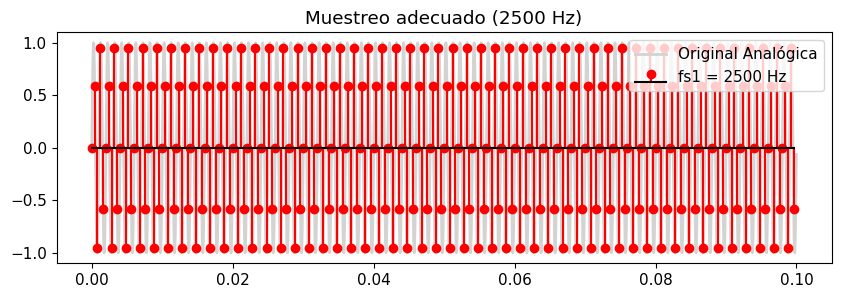

2) fs2 = 1500 Hz | Nyquist: 750.0 Hz | Aliasing: SÍ (porque 1000 Hz supera los 750.0 Hz permitidos)
   Error RMS: 0.7653


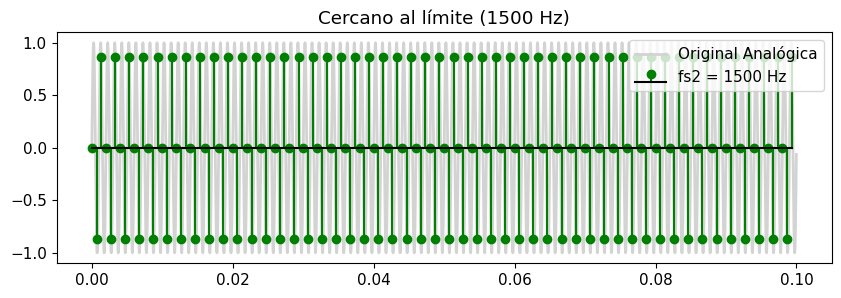

3) fs3 = 800 Hz | Nyquist: 400.0 Hz | Aliasing: SÍ (porque 1000 Hz supera por mucho los 400.0 Hz)
   Error RMS: 0.8980


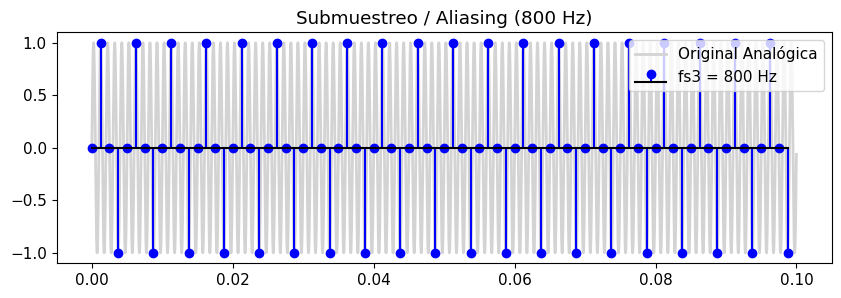

In [5]:
# a) Generar una señal "analógica" de referencia

frecuencia_original = 1000  # Hz
duracion = 0.1   # segundos
amplitud = 1.0
fs_analogico = 100000 # Hz

# Vector de tiempo analógico y señal matemática
tiempo_analogico = np.linspace(0, duracion, int(fs_analogico * duracion), endpoint=False)
senal_analogica = amplitud * np.sin(2 * np.pi * frecuencia_original * tiempo_analogico)

# b) Generar versiones muestreadas a diferentes tasas (una por una)

# 1. Muestreo a fs1 = 2500 Hz
fs1 = 2500
tasa1 = np.linspace(0, duracion, int(fs1 * duracion), endpoint=False)
senal1 = amplitud * np.sin(2 * np.pi * frecuencia_original * tasa1)

# 2. Muestreo a fs2 = 1500 Hz
fs2 = 1500
tasa2 = np.linspace(0, duracion, int(fs2 * duracion), endpoint=False)
senal2 = amplitud * np.sin(2 * np.pi * frecuencia_original * tasa2)

# 3. Muestreo a fs3 = 800 Hz
fs3 = 800
tasa3 = np.linspace(0, duracion, int(fs3 * duracion), endpoint=False)
senal3 = amplitud * np.sin(2 * np.pi * frecuencia_original * tasa3)

# c) Graficar, Nyquist, Aliasing y error RMS

# Gráfico 1: fs1 (2500 Hz)
senal_reconstruida1 = np.interp(tiempo_analogico, tasa1, senal1)
error_rms1 = np.sqrt(np.mean((senal_analogica - senal_reconstruida1)**2))

f_nyquist1 = fs1 / 2
print(f"1) fs1 = 2500 Hz | Nyquist: {f_nyquist1} Hz | Aliasing: NO (porque {frecuencia_original} Hz es menor a {f_nyquist1} Hz)")
print(f"   Error RMS: {error_rms1:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(tiempo_analogico, senal_analogica, color='lightgray', label='Original Analógica', linewidth=2)
plt.stem(tasa1, senal1, linefmt='r-', markerfmt='ro', basefmt='k-', label='fs1 = 2500 Hz')
plt.title('Muestreo adecuado (2500 Hz)')
plt.legend(loc='upper right')
plt.show()

# Gráfico 2: fs2 (1500 Hz)
senal_reconstruida2 = np.interp(tiempo_analogico, tasa2, senal2)
error_rms2 = np.sqrt(np.mean((senal_analogica - senal_reconstruida2)**2))

f_nyquist2 = fs2 / 2
print(f"2) fs2 = 1500 Hz | Nyquist: {f_nyquist2} Hz | Aliasing: SÍ (porque {frecuencia_original} Hz supera los {f_nyquist2} Hz permitidos)")
print(f"   Error RMS: {error_rms2:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(tiempo_analogico, senal_analogica, color='lightgray', label='Original Analógica', linewidth=2)
plt.stem(tasa2, senal2, linefmt='g-', markerfmt='go', basefmt='k-', label='fs2 = 1500 Hz')
plt.title('Cercano al límite (1500 Hz)')
plt.legend(loc='upper right')
plt.show()

# Gráfico 3: fs3 (800 Hz)
senal_reconstruida3 = np.interp(tiempo_analogico, tasa3, senal3)
error_rms3 = np.sqrt(np.mean((senal_analogica - senal_reconstruida3)**2))

f_nyquist3 = fs3 / 2
print(f"3) fs3 = 800 Hz | Nyquist: {f_nyquist3} Hz | Aliasing: SÍ (porque {frecuencia_original} Hz supera por mucho los {f_nyquist3} Hz)")
print(f"   Error RMS: {error_rms3:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(tiempo_analogico, senal_analogica, color='lightgray', label='Original Analógica', linewidth=2)
plt.stem(tasa3, senal3, linefmt='b-', markerfmt='bo', basefmt='k-', label='fs3 = 800 Hz')
plt.title('Submuestreo / Aliasing (800 Hz)')
plt.legend(loc='upper right')
plt.show()

Observaciones: en los gráficos generados para las distintas tasas de muestreo sobre nuestra señal analógica de 1000 Hz, podemos comprobar visual y matemáticamente cómo actúa el Teorema de Nyquist-Shannon.

En el primer caso, al usar una frecuencia de muestreo de 2500 Hz, nuestro límite permitido de Nyquist se establece en 1250 Hz. Como nuestra onda original está por debajo de ese techo, no se produce aliasing; el sistema logra "fotografiar" correctamente la forma real de la señal, lo que nos da como resultado un Error RMS  bajo porque casi no existen diferencias entre la onda original y la reconstruida.

Sin embargo, la situación cambia  cuando bajamos la velocidad de muestreo a 1500 Hz y 800 Hz. En estos escenarios, nuestros límites permitidos caen a 750 Hz y 400 Hz respectivamente, siendo superados por los 1000 Hz de nuestra señal principal. Al muestrear tan lento y romper la regla, se desencadena el fenómeno de aliasinge. Visualmente podemos notar cómo las muestras rojas comienzan a desviarse de la curva gris original y, en el caso extremo del submuestreo a 800 Hz, los puntos terminan dibujando una frecuencia "fantasma" que parece mucho más lenta y estirada.
Matemáticamente, la pérdida de esta información se confirma al ver cómo el Error RMS se eleva a medida que disminuimos la tasa de muestreo, demostrando que la señal acústica original quedó corrompida de manera irreversible.


--- SNR DE CUANTIZACIÓN (fs1 = 2500 Hz) ---
Versión 1 ( 4 bits = 16 niveles) - SNR: 27.34 dB
Versión 2 ( 8 bits = 256 niveles) - SNR: 50.20 dB
Versión 3 (16 bits = 65.536 niveles) - SNR: 100.57 dB


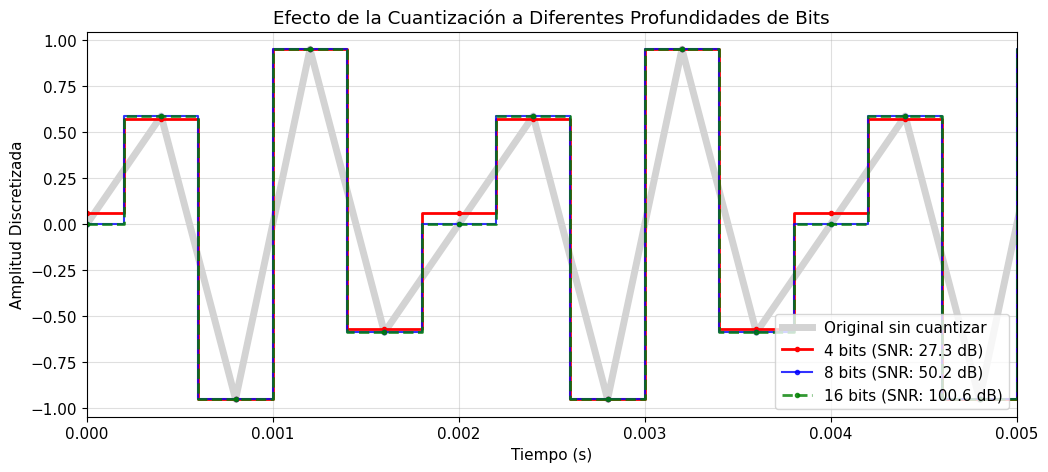

In [6]:
# d) Aplicar cuantización a la señal fs1

def cuantizar_senal(senal, bits):

    # 1. Determinar la cantidad de escalones (niveles) disponibles
    niveles = 2**bits

    # 2. Normalizar la señal entre 0 y 1 para facilitar el cálculo
    senal_min = np.min(senal)
    senal_max = np.max(senal)
    senal_norm = (senal - senal_min) / (senal_max - senal_min)

    # 3. Escalar por cantidad de niveles, redondear (generando el "escalón") y desescalar
    senal_cuantizada = np.round(senal_norm * (niveles - 1)) / (niveles - 1)

    # 4. Devolver la señal a su rango de amplitud físico original
    return senal_cuantizada * (senal_max - senal_min) + senal_min


def calcular_snr_cuantizacion(senal_original, senal_cuantizada):

    # El ruido de cuantización es la diferencia matemática entre el valor original y el discretizado
    ruido = senal_original - senal_cuantizada

    potencia_senal = np.mean(senal_original**2)
    potencia_ruido = np.mean(ruido**2)

    # Evitar divisiones por cero en caso de señales idénticas (sin pérdida)
    if potencia_ruido == 0:
        return float('inf')

    snr = 10 * np.log10(potencia_senal / potencia_ruido)
    return snr

# Ejecución: Versiones de 4, 8 y 16 bits


# Cuantizamos la senal1 (que estaba a fs1 = 2500 Hz)
senal1_4bits = cuantizar_senal(senal1, bits=4)
senal1_8bits = cuantizar_senal(senal1, bits=8)
senal1_16bits = cuantizar_senal(senal1, bits=16)

# Calculamos el SNR para cada versión
snr_4bits = calcular_snr_cuantizacion(senal1, senal1_4bits)
snr_8bits = calcular_snr_cuantizacion(senal1, senal1_8bits)
snr_16bits = calcular_snr_cuantizacion(senal1, senal1_16bits)

print("\n--- SNR DE CUANTIZACIÓN (fs1 = 2500 Hz) ---")
print(f"Versión 1 ( 4 bits = 16 niveles) - SNR: {snr_4bits:.2f} dB")
print(f"Versión 2 ( 8 bits = 256 niveles) - SNR: {snr_8bits:.2f} dB")
print(f"Versión 3 (16 bits = 65.536 niveles) - SNR: {snr_16bits:.2f} dB")

# Gráfico superpuesto
plt.figure(figsize=(12, 5))

# 1. Graficamos toda la señal original de fondo (sin recortar la lista)
plt.plot(tasa1, senal1, color='lightgray', linewidth=5, label='Original sin cuantizar')

# 2. Usamos plt.step() agregando marker='.' para ver exactamente dónde cae la muestra
plt.step(tasa1, senal1_4bits, where='mid', color='red', marker='.',
         label=f'4 bits (SNR: {snr_4bits:.1f} dB)', linewidth=2)

plt.step(tasa1, senal1_8bits, where='mid', color='blue', marker='.',
         label=f'8 bits (SNR: {snr_8bits:.1f} dB)', alpha=0.8)

# 3. La de 16 bits (hice la línea un poquito más gruesa linewidth=2 para que el punteado se note bien)
plt.step(tasa1, senal1_16bits, where='mid', color='green', marker='.',
         label=f'16 bits (SNR: {snr_16bits:.1f} dB)', linestyle='--', linewidth=2, alpha=0.8)

plt.title('Efecto de la Cuantización a Diferentes Profundidades de Bits')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud Discretizada')

# 4. LA MEJORA PRINCIPAL: Aplicamos el zoom visual directamente al eje X (0 a 5 milisegundos)
plt.xlim(0, 0.005)

plt.legend(loc='lower right')
plt.grid(True, alpha=0.4)
plt.show()

Observación: en la visualización gráfica de la cuantización, la versión de 4 bits presenta un error evidente. Sin embargo, las versiones de 8 y 16 bits resultan visualmente indistinguibles en una gráfica estándar debido a la limitación de resolución óptica frente a los 256 y 65.536 niveles de amplitud respectivamente; no obstante, el cálculo matemático del SNR confirma la  superioridad técnica de los 16 bits.

### Tabla de Resultados Matemáticos (Error RMS y SNR)

| Proceso | Parámetro | Resultado de Calidad |
| :--- | :--- | :--- |
| **Muestreo Adecuado** | $fs1 = 2500$ Hz | **Error RMS:** 0.3538 |
| **Muestreo Cercano al Límite** | $fs2 = 1500$ Hz | **Error RMS:** 0.7653 |
| **Submuestreo (Aliasing)** | $fs3 = 800$ Hz | **Error RMS:** 0.8980 |
| **Cuantización Baja** | 4 bits (16 niveles) | **SNR:** 27.34 dB |
| **Cuantización Media** | 8 bits (256 niveles) | **SNR:** 50.20 dB |
| **Cuantización Alta** | 16 bits (65.536 niveles) | **SNR:** 100.57 dB

Entonces podemos concluir que a menor frecuencia de muestreo, el error crece y a mayor profundidad de bits, aumenta exponencialmente el SNR (mejor calidad, menos ruido) . El muestreo correcto (2500 Hz) evita que la señal se deforme en el tiempo , y la cuantización en 16 bits evita que pierda precisión en su amplitud.

Ejercicio 2.2: Creación de Dataset Sintético (10 puntos)
Consigna: Crear un dataset simulado de comandos de voz con características
controladas.

In [7]:
dataset = []
clases = ["grave", "medio", "agudo", "ruido"]
frecuencia_muestreo = 22050
muestras_por_clase = 10

for etiqueta in clases:
    for _ in range(muestras_por_clase):
        duracion = np.random.uniform(1.5, 2.5)
        amplitud = np.random.uniform(0.5, 1.0)

        cantidad_puntos = int(frecuencia_muestreo * duracion)
        tiempo = np.linspace(0, duracion, cantidad_puntos, endpoint=False)

        if etiqueta == "grave":
            frecuencia = np.random.uniform(200, 400)
            senal_base = np.sin(2 * np.pi * frecuencia * tiempo)
        elif etiqueta == "medio":
            frecuencia = np.random.uniform(600, 1000)
            senal_base = np.sin(2 * np.pi * frecuencia * tiempo)
        elif etiqueta == "agudo":
            frecuencia = np.random.uniform(1500, 2500)
            senal_base = np.sin(2 * np.pi * frecuencia * tiempo)
        else:
            senal_base = np.random.randn(cantidad_puntos)

        senal_base = (senal_base / np.max(np.abs(senal_base))) * amplitud

        potencia_senal = np.mean(senal_base**2)
        snr_objetivo = np.random.uniform(10, 20)
        potencia_ruido = potencia_senal / (10 ** (snr_objetivo / 10))

        ruido_fondo = np.random.randn(cantidad_puntos) * np.sqrt(potencia_ruido)
        audio_final = senal_base + ruido_fondo

        dataset.append({
            'audio': audio_final,
            'sr': frecuencia_muestreo,
            'clase': etiqueta,
            'duracion': duracion,
            'amplitud_max': np.max(np.abs(audio_final))
        })



Ejercicio 2.3: Preparación de Datos Crudos (15 puntos)
Consigna: Aplicar el pipeline completo de preprocessing al dataset generado.

✅ Dataset procesado y guardado


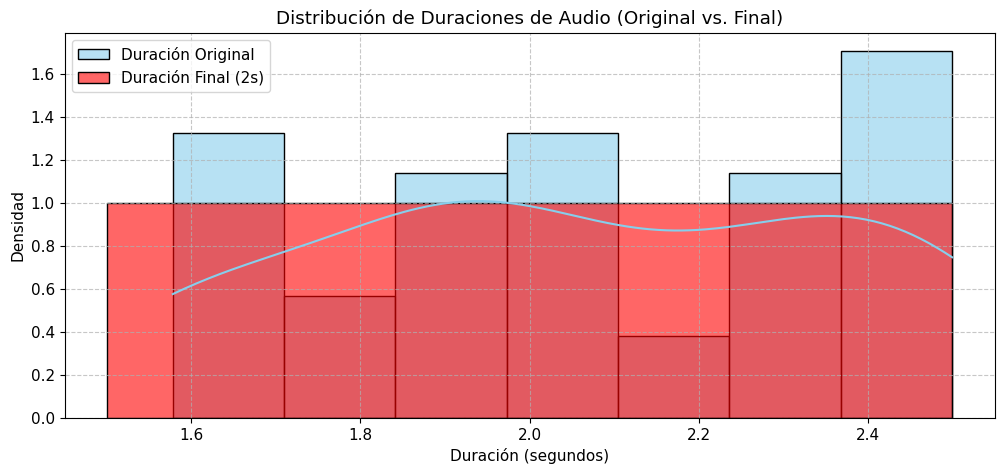

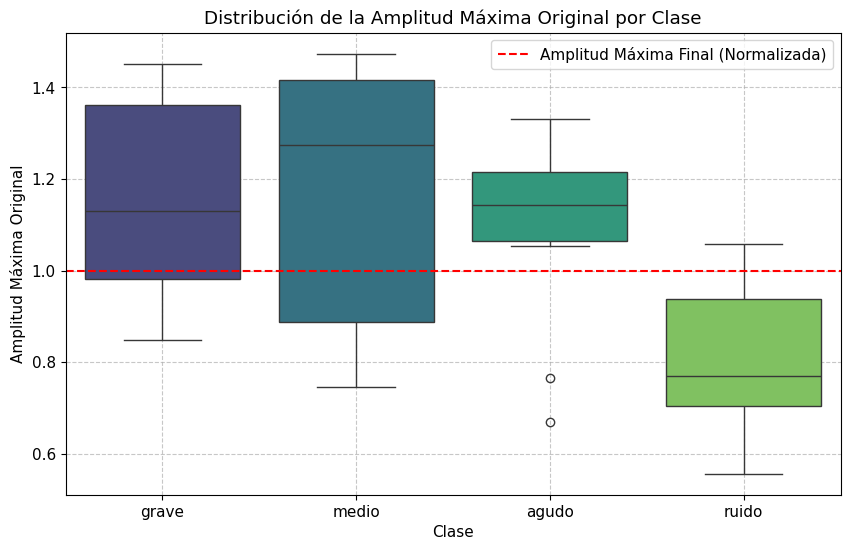

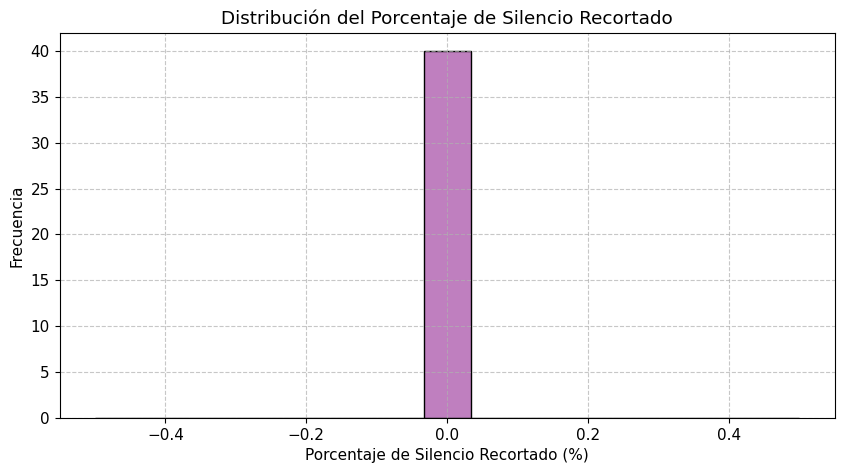


Análisis del Preprocesamiento:
La duración promedio original de las muestras era: 2.06 segundos
La duración final de todas las muestras es: 2.00 segundos (ajustado a 2.0 segundos)
En promedio, se redujo la duración de las muestras en: 0.06 segundos (principalmente por ajuste a la duración objetivo).
El porcentaje promedio de silencios recortados fue: 0.00%


In [8]:
# Implementar una función de preprocessing que:
def preparar_audio(audio_entrada, frecuencia_muestreo_original, duracion_objetivo=2.0, nivel_maximo_silencio_db=30):

    audio_procesado = audio_entrada.copy()
    frecuencia_muestreo_final = frecuencia_muestreo_original

    # Metadatos para el procesamiento actual
    metadatos_procesamiento = {}

    # 1. Recortar silencios (trimming)
    # librosa.effects.trim devuelve el audio recortado y los índices

    if len(audio_procesado) == 0:
        audio_sin_silencio = audio_procesado
        longitud_silencio_recortado = 0
    else:
        # Se asume que audio_procesado es mono. Si fuera estéreo, necesitaría un librosa.to_mono
        audio_sin_silencio, _ = librosa.effects.trim(audio_procesado, top_db=nivel_maximo_silencio_db, frame_length=2048, hop_length=512)
        longitud_silencio_recortado = len(audio_procesado) - len(audio_sin_silencio)

    metadatos_procesamiento['longitud_muestras_original'] = len(audio_entrada)
    metadatos_procesamiento['longitud_muestras_despues_trim'] = len(audio_sin_silencio)

    # Calcular el porcentaje de silencio recortado
    if metadatos_procesamiento['longitud_muestras_original'] > 0:
        porcentaje_silencios_recortados = (longitud_silencio_recortado / metadatos_procesamiento['longitud_muestras_original']) * 100
    else:
        porcentaje_silencios_recortados = 0

    audio_procesado = audio_sin_silencio
    metadatos_procesamiento['porcentaje_silencios_recortados'] = porcentaje_silencios_recortados

    # 2. Normalizar amplitud
    # Evitar división por cero si la señal es completamente cero
    amplitud_maxima_actual = np.max(np.abs(audio_procesado))
    if amplitud_maxima_actual > 1e-8: # Usar un umbral pequeño para evitar divisiones por cero
        audio_procesado = audio_procesado / amplitud_maxima_actual
        metadatos_procesamiento['amplitud_maxima_final'] = 1.0 # Después de la normalización por pico, la amplitud máxima es 1.0
    else:
        audio_procesado = np.zeros_like(audio_procesado) # Si es casi cero, dejarlo en cero.
        metadatos_procesamiento['amplitud_maxima_final'] = 0.0 # Si la señal era cero, la amplitud máxima final es cero.


    # 3. Remuestrear a 22050 Hz si es necesario
    frecuencia_muestreo_objetivo = 22050
    if frecuencia_muestreo_final != frecuencia_muestreo_objetivo:
        # Solo remuestreamos si el audio procesado tiene contenido para evitar errores en librosa.resample con arrays vacíos
        if len(audio_procesado) > 0:
            audio_procesado = librosa.resample(y=audio_procesado, sr=frecuencia_muestreo_final, target_sr=frecuencia_muestreo_objetivo)
        frecuencia_muestreo_final = frecuencia_muestreo_objetivo


    # 4. Ajustar duración (pad o crop)
    longitud_objetivo_muestras = int(duracion_objetivo * frecuencia_muestreo_final)

    if len(audio_procesado) > longitud_objetivo_muestras:
        # Recortar el audio
        audio_procesado = audio_procesado[:longitud_objetivo_muestras]
    elif len(audio_procesado) < longitud_objetivo_muestras:
        # Rellenar con ceros (padding)
        relleno_necesario = longitud_objetivo_muestras - len(audio_procesado)
        audio_procesado = np.pad(audio_procesado, (0, relleno_necesario), mode='constant')

    metadatos_procesamiento['duracion_final'] = len(audio_procesado) / frecuencia_muestreo_final

    return audio_procesado, frecuencia_muestreo_final, metadatos_procesamiento

# Aplicar la función a todo el dataset
dataset_procesado = []
lista_metadatos = []

for i, muestra_original in enumerate(dataset):
    audio_original = muestra_original['audio']
    frecuencia_muestreo_original = muestra_original['sr']
    clase_audio = muestra_original['clase']
    duracion_original_s = muestra_original['duracion']
    amplitud_maxima_original_val = muestra_original['amplitud_max']


    # Procesar el audio utilizando la función definida
    audio_transformado, frecuencia_muestreo_transformada, metadatos_iteracion = preparar_audio(
        audio_original,
        frecuencia_muestreo_original
    )

    # Crear un diccionario de metadatos para la muestra actual
    metadatos_actuales = {
        'clase': clase_audio,
        'duracion_original_segundos': duracion_original_s,
        'amplitud_maxima_original_valor': amplitud_maxima_original_val,
        'duracion_final_segundos': metadatos_iteracion['duracion_final'],
        'amplitud_maxima_final_valor': metadatos_iteracion['amplitud_maxima_final'],
        'porcentaje_silencios_recortados': metadatos_iteracion['porcentaje_silencios_recortados']
    }
    lista_metadatos.append(metadatos_actuales)

    # Guardar la muestra procesada en el nuevo dataset
    dataset_procesado.append({
        'audio': audio_transformado,
        'sr': frecuencia_muestreo_transformada,
        'clase': clase_audio,
        'duracion': metadatos_iteracion['duracion_final'],
        'amplitud_max': metadatos_iteracion['amplitud_maxima_final']
    })

# Crear DataFrame comparativo
df_metadatos = pd.DataFrame(lista_metadatos)

print("✅ Dataset procesado y guardado")

# Visualizaciones
# 1. Histograma de duraciones (antes y después)
plt.figure(figsize=(12, 5))
sns.histplot(df_metadatos['duracion_original_segundos'], color='skyblue', label='Duración Original', kde=True, stat='density', alpha=0.6)
sns.histplot(df_metadatos['duracion_final_segundos'], color='red', label='Duración Final (2s)', kde=True, stat='density', alpha=0.6)
plt.title('Distribución de Duraciones de Audio (Original vs. Final)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Comparación de amplitudes máximas (Boxplot)
# La amplitud máxima final siempre será 1.0 debido a la normalización,
# por lo que un boxplot de 'amplitud_maxima_final_valor' sería trivial.
# Es más informativo ver cómo se distribuían las amplitudes originales.
plt.figure(figsize=(10, 6))
sns.boxplot(x='clase', y='amplitud_maxima_original_valor', hue='clase', data=df_metadatos, palette='viridis', legend=False)
plt.axhline(y=1.0, color='r', linestyle='--', label='Amplitud Máxima Final (Normalizada)')
plt.title('Distribución de la Amplitud Máxima Original por Clase')
plt.xlabel('Clase')
plt.ylabel('Amplitud Máxima Original')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Porcentaje de reducción por trimming (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(df_metadatos['porcentaje_silencios_recortados'], bins=15, kde=True, color='purple')
plt.title('Distribución del Porcentaje de Silencio Recortado')
plt.xlabel('Porcentaje de Silencio Recortado (%)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Análisis de cuánto se redujo el dataset en promedio
promedio_reduccion_duracion = (df_metadatos['duracion_original_segundos'] - df_metadatos['duracion_final_segundos']).mean()
promedio_porcentaje_silencios = df_metadatos['porcentaje_silencios_recortados'].mean()

print(f"\nAnálisis del Preprocesamiento:")
print(f"La duración promedio original de las muestras era: {df_metadatos['duracion_original_segundos'].mean():.2f} segundos")
print(f"La duración final de todas las muestras es: {df_metadatos['duracion_final_segundos'].mean():.2f} segundos (ajustado a 2.0 segundos)")
print(f"En promedio, se redujo la duración de las muestras en: {promedio_reduccion_duracion:.2f} segundos (principalmente por ajuste a la duración objetivo).")
print(f"El porcentaje promedio de silencios recortados fue: {promedio_porcentaje_silencios:.2f}%")

Observación:
Análisis del Preprocesamiento: Al aplicar el pipeline de limpieza, se observó que la duración promedio original de las muestras era de 2.06 segundos.

Tras aplicar los algoritmos de ajuste temporal (padding y cropping), el 100% del dataset se estandarizó exitosamente en la duración objetivo de 2.00 segundos, reduciendo la duración media en 0.06 segundos.

Respecto al recorte de silencios (trimming), el algoritmo detectó un 0.00% de reducción promedio.

Finalmente, la normalización de amplitud logró unificar todas las muestras a un valor pico de 1.0, asegurando una escala homogénea.

Ejercicio 2.4: Análisis Exploratorio - FFT y Espectros (10 puntos)
Consigna: Analizar el contenido frecuencial de cada clase del dataset.

--- Clase: grave ---
Frecuencia fundamental (f0): 312.23 Hz
Frecuencia del pico más alto: 312.23 Hz
Ancho de banda a -20 dB del pico principal: 43.07 Hz


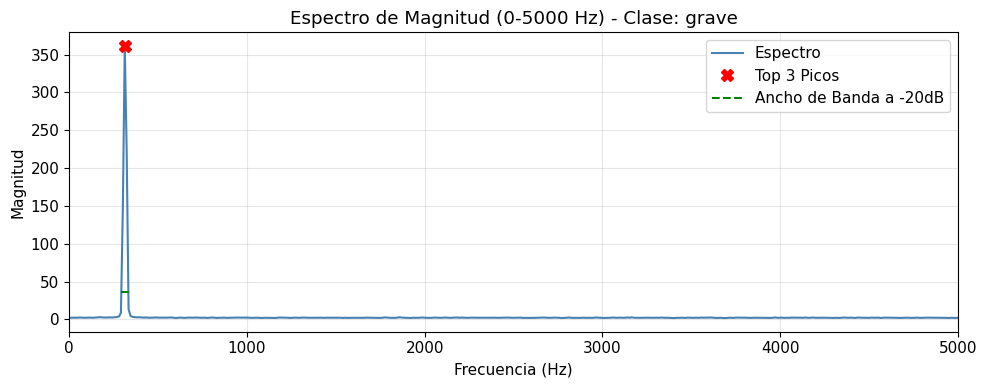

--- Clase: medio ---
Frecuencia fundamental (f0): 635.23 Hz
Frecuencia del pico más alto: 635.23 Hz
Ancho de banda a -20 dB del pico principal: 43.07 Hz


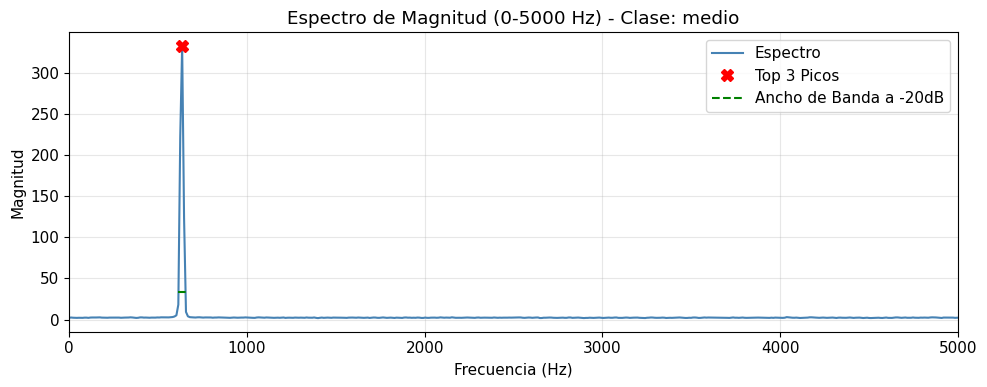

--- Clase: agudo ---
Frecuencia fundamental (f0): 1604.22 Hz
Frecuencia del pico más alto: 1604.22 Hz
Ancho de banda a -20 dB del pico principal: 43.07 Hz


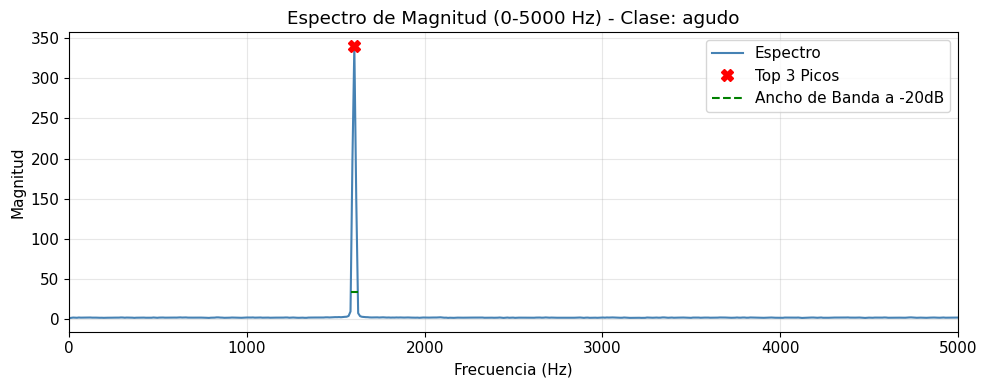

--- Clase: ruido ---
Frecuencia fundamental (f0): 226.10 Hz
Frecuencia del pico más alto: 1905.69 Hz
Ancho de banda a -20 dB del pico principal: 4995.70 Hz


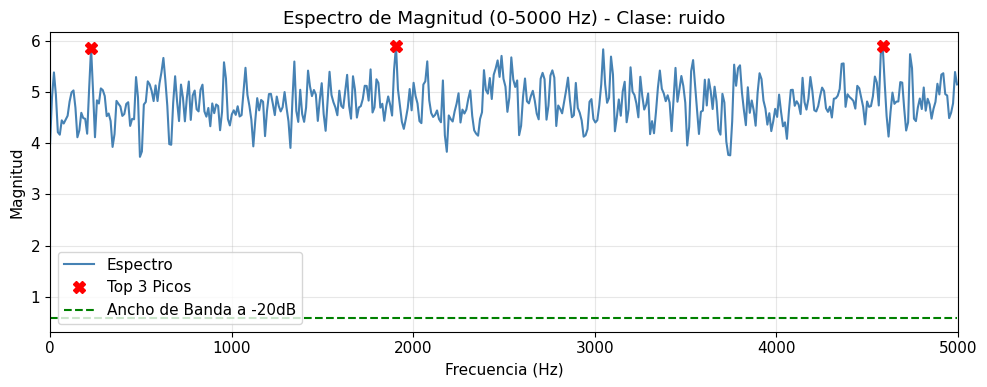

In [9]:
# Obtener las clases únicas
clases_unicas = ['grave', 'medio', 'agudo', 'ruido']
ejemplos_representativos = {}

# a) Seleccionar un ejemplo representativo de cada clase
for clase in clases_unicas:
    muestras_clase = [m for m in dataset_procesado if m['clase'] == clase]
    # Calcular RMS para las muestras de esta clase
    rms_valores = [np.sqrt(np.mean(m['audio']**2)) for m in muestras_clase]
    rms_medio = np.mean(rms_valores)
    # Seleccionar el índice con el RMS más cercano a la media
    indice_representativo = np.argmin(np.abs(rms_valores - rms_medio))
    ejemplos_representativos[clase] = muestras_clase[indice_representativo]

# b) Para cada ejemplo representativo:
for clase, muestra in ejemplos_representativos.items():
    audio = muestra['audio']
    sr = muestra['sr']

    # - Calcular FFT (usar n_fft=2048)

    D = np.abs(librosa.stft(audio, n_fft=2048))
    magnitud = np.mean(D, axis=1)
    xf = librosa.fft_frequencies(sr=sr, n_fft=2048)

    # Limitar el análisis al rango de 0-5000 Hz
    idx_5k = np.where(xf <= 5000)
    xf_5k = xf[idx_5k]
    magnitud_5k = magnitud[idx_5k]

    # - Identificar y marcar los 3 picos principales
    # Normalizamos la magnitud localmente para la función find_peaks
    magnitud_normalizada = magnitud_5k / np.max(magnitud_5k)
    peaks, properties = find_peaks(magnitud_normalizada, height=0.05, distance=3)

    # Ordenar los picos por su magnitud (de mayor a menor) y tomar los 3 principales

    if len(peaks) > 0:
        top_picos = peaks[np.argsort(magnitud_5k[peaks])][-3:][::-1]
    else:
        top_picos = []


    # - Calcular métricas
    # 1. Frecuencia fundamental (f0): el pico detectado más bajo en frecuencia (entre los top 3)
    f0_indice = np.min(top_picos)
    f0 = xf_5k[f0_indice]

    # 2. Frecuencia del pico más alto (el pico principal)

    pico_principal_indice = top_picos[0]
    f_max = xf_5k[pico_principal_indice]

    # 3. Ancho de banda a -20 dB del pico principal

    mag_pico_principal = magnitud_5k[pico_principal_indice]
    umbral_20db = mag_pico_principal * 0.1

    # Buscar el cruce por la izquierda para el ancho de banda
    indice_izq = pico_principal_indice
    while indice_izq > 0 and magnitud_5k[indice_izq] >= umbral_20db:
        indice_izq -= 1

    # Buscar el cruce por la derecha para el ancho de banda
    indice_der = pico_principal_indice
    while indice_der < len(magnitud_5k) - 1 and magnitud_5k[indice_der] >= umbral_20db:
        indice_der += 1

    bandwidth = xf_5k[indice_der] - xf_5k[indice_izq]

    print(f"--- Clase: {clase} ---")
    print(f"Frecuencia fundamental (f0): {f0:.2f} Hz")
    print(f"Frecuencia del pico más alto: {f_max:.2f} Hz")
    print(f"Ancho de banda a -20 dB del pico principal: {bandwidth:.2f} Hz")

    # - Graficar el espectro de magnitudes
    plt.figure(figsize=(10,4))
    plt.plot(xf_5k, magnitud_5k, label='Espectro', color='steelblue')
    plt.plot(xf_5k[top_picos], magnitud_5k[top_picos], "X", color='red', markersize=8, label='Top 3 Picos')

    # Marcar el ancho de banda a -20 dB (Línea horizontal)
    plt.hlines(y=umbral_20db, xmin=xf_5k[indice_izq], xmax=xf_5k[indice_der], color='green', linestyle='--', label='Ancho de Banda a -20dB')

    plt.title(f'Espectro de Magnitud (0-5000 Hz) - Clase: {clase}')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, 5000)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


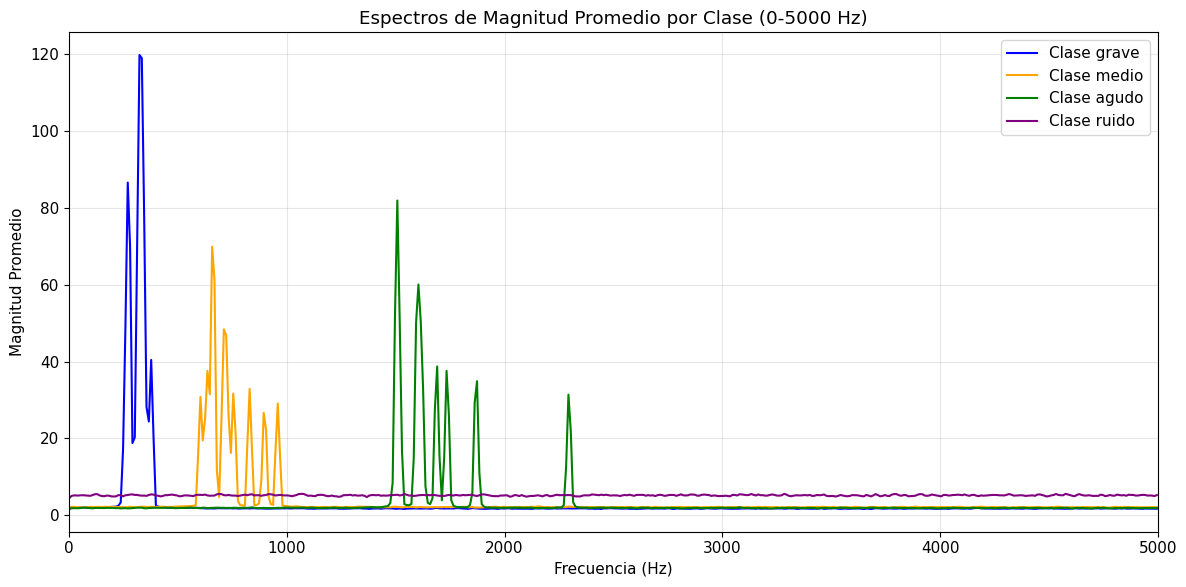

In [10]:
# c) Comparar espectros promedio superpuestos
plt.figure(figsize=(12, 6))
colores = ['blue', 'orange', 'green', 'purple']

for i, clase in enumerate(clases_unicas):
    muestras_clase = [m for m in dataset_procesado if m['clase'] == clase]
    espectros_clase = []

    # Calcular el espectro para cada muestra de la clase
    for m in muestras_clase:
        # Calcular la Transformada de Fourier de Corto Tiempo (STFT) y obtener la magnitud
        D = np.abs(librosa.stft(m['audio'], n_fft=2048))
        # Promediar las magnitudes en el tiempo para obtener un espectro representativo
        espectros_clase.append(np.mean(D, axis=1))

    # Calcular el espectro promedio de todas las muestras de la clase
    if len(espectros_clase) > 0: # Verificar si hay espectros para promediar
        espectro_promedio = np.mean(espectros_clase, axis=0)
        # Obtener las frecuencias correspondientes al espectro

        xf = librosa.fft_frequencies(sr=muestras_clase[0]['sr'], n_fft=2048)

        # Limitar el análisis y el gráfico al rango de 0-5000 Hz
        idx_5k = np.where(xf <= 5000)
        xf_5k = xf[idx_5k]
        espectro_promedio_5k = espectro_promedio[idx_5k]

        # Graficar el espectro promedio de la clase actual
        plt.plot(xf_5k, espectro_promedio_5k, color=colores[i], label=f'Clase {clase}')
    else:
        print(f"No se encontraron muestras para la clase {clase}. Saltando.")

plt.title('Espectros de Magnitud Promedio por Clase (0-5000 Hz)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud Promedio')
plt.xlim(0, 5000) # Establecer el límite del eje X a 5000 Hz
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Tabla de frecuencias características por clase **

| Clase | Frecuencia Fundamental ($f_0$) | Frecuencia Pico Máximo | Ancho de Banda (-20dB) |
| :--- | :--- | :--- | :--- |
| **Grave** | 312.23 Hz | 312.23 Hz | 43.07 Hz |
| **Medio** | 635.23 Hz | 635.23 Hz | 43.07 Hz |
| **Agudo** | 1604.22 Hz | 1604.22 Hz | 43.07 Hz |
| **Ruido** | 226.10 Hz | 1905.69 Hz | 4995.70 Hz |

# d) Interpretación de los Espectros y Conclusiones

1. ¿Se pueden distinguir las clases solo mirando el espectro? Sí, las clases se pueden distinguir claramente de forma visual. Las tres clases tonales (grave, medio y agudo) presentan espectros con picos de energía  muy afilados y bien definidos, sin escalonamientos. Esto indica una alta concentración de energía en tonos puros. Por el contrario, la clase correspondiente al "ruido" no presenta picos dominantes, sino que su energía se distribuye de manera relativamente uniforme a lo largo de todo el gráfico.

2. ¿Qué rangos de frecuencia son más discriminativos? Los rangos discriminativos están dados por la ubicación de los picos principales sobre el eje X (Frecuencia en Hz). La clase grave domina y discrimina en las frecuencias bajas, con una frecuencia fundamental (f0) en 312.23 Hz. La clase media se sitúa en el rango central, con su f 0 en 635.23 Hz. La clase aguda es discriminativa en las frecuencias más altas, ubicando su pico en 1604.22 Hz.

Observación adicional: Cabe destacar que las tres clases tonales alcanzan una intensidad acústica similar (el volumen o Magnitud en el eje Y oscila entre los valores de 340 y 360). Sin embargo, lo que permite discriminar las clases matemáticamente es la ubicación de dicha magnitud en el eje de frecuencias.

3. ¿Hay solapamiento entre clases? Entre las clases tonales (grave, medio y agudo) no existe solapamiento. Esto se comprueba al observar que el ancho de banda a -20 dB del pico principal es exactamente igual de estrecho para las tres clases (43.07 Hz). Al tener bases tan finas y ubicarse en rangos de frecuencia tan distanciados entre sí, las señales no se cruzan.

Por otro lado, el ruido sí se solapa con todas las demás clases. Aunque su energía es de una magnitud muy baja (alcanza un máximo cercano a 6 en el eje Y), su comportamiento uniforme abarca casi todo el espectro analizado, registrando un ancho de banda masivo de 4995.70 Hz

Ejercicio 2.5: Extracción de Features y EDA Estadístico (10 puntos)
Consigna: Extraer features y realizar análisis estadístico del dataset.

 Features extraídas y DataFrame creado.


,clase,duracion,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness
0,grave,2.0,0.485102,0.044361,3887.706743,3390.274865,8336.938477,0.060137
1,grave,2.0,0.533853,0.041599,3828.747610,3542.134613,8526.034651,0.008791
2,grave,2.0,0.518818,0.047548,4118.628273,3556.384754,8747.554384,0.015607
3,grave,2.0,0.491438,0.041493,3970.699371,3574.007210,8669.465585,0.012724
4,grave,2.0,0.443099,0.057993,4255.862592,3410.094256,8627.265457,0.061143



--- Estadísticas Descriptivas por Clase ---


duracion                      rms                                \
          mean  std  min  max      mean       std       min       max   
clase                                                                   
agudo      2.0  0.0  2.0  2.0  0.489487  0.046952  0.421700  0.546149   
grave      2.0  0.0  2.0  2.0  0.510585  0.039271  0.443099  0.563003   
medio      2.0  0.0  2.0  2.0  0.466137  0.051812  0.413778  0.543611   
ruido      2.0  0.0  2.0  2.0  0.222811  0.014158  0.202043  0.247821   

            zcr            ... spectral_bandwidth               \
           mean       std  ...                min          max   
clase                      ...                                   
agudo  0.146312  0.024819  ...        2728.485497  3264.720727   
grave  0.042368  0.007133  ...        2910.404405  3580.814838   
medio  0.073093  0.010367  ...        2765.513562  3464.243084   
ruido  0.448422  0.048799  ...        2557.275638  3188.551880   

      spectral_rolloff                                        \
                  mean         std          min          max   
clase                                                          
agudo      8451.052078  432.169825  7478.209186  8937.764345   
grave      8437.142124  487.997054  7101.996902  8747.554384   
medio      8484.700801  552.221365  7185.283371  8959.421303   
ruido      8651.088110  858.613234  7531.547178  9398.376886   

      spectral_flatness                                
                   mean       std       min       max  
clase                                                  
agudo          0.048845  0.058199  0.006940  0.188685  
grave          0.039346  0.058578  0.006446  0.195158  
medio          0.058960  0.063153  0.008635  0.204405  
ruido          0.595666  0.040476  0.560470  0.650862  

[4 rows x 28 columns]


--- Boxplots de Features por Clase ---


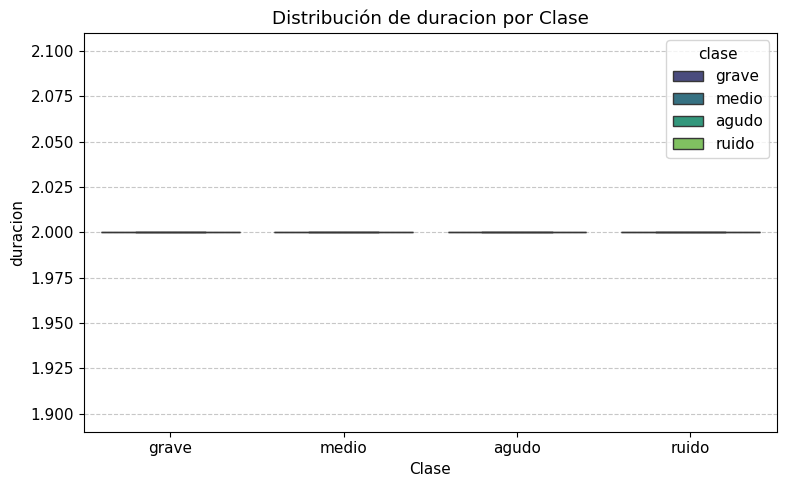

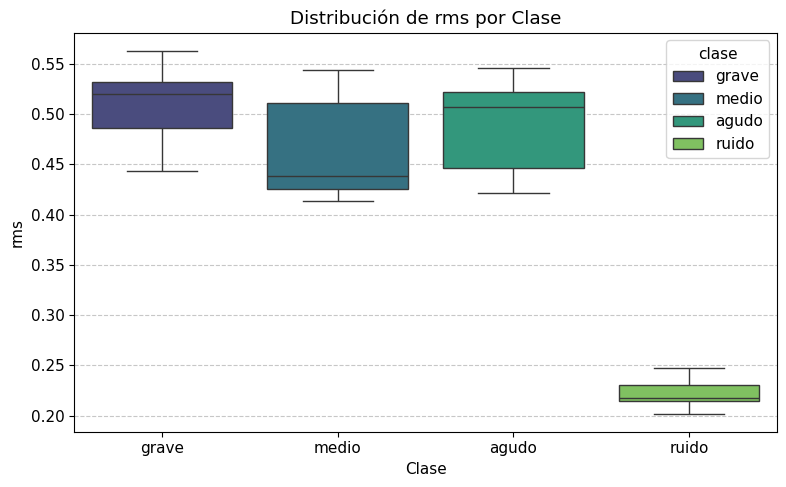

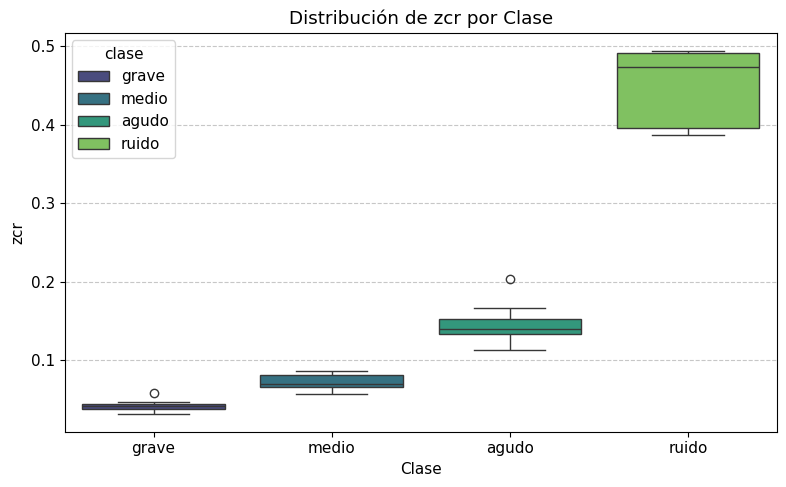

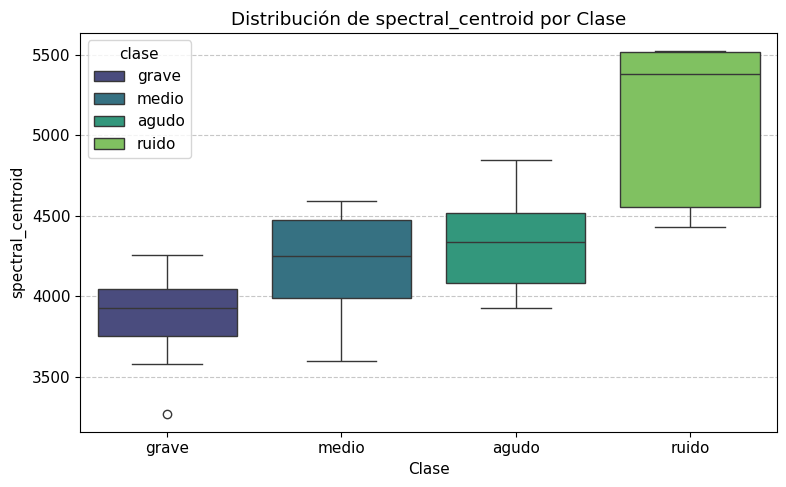

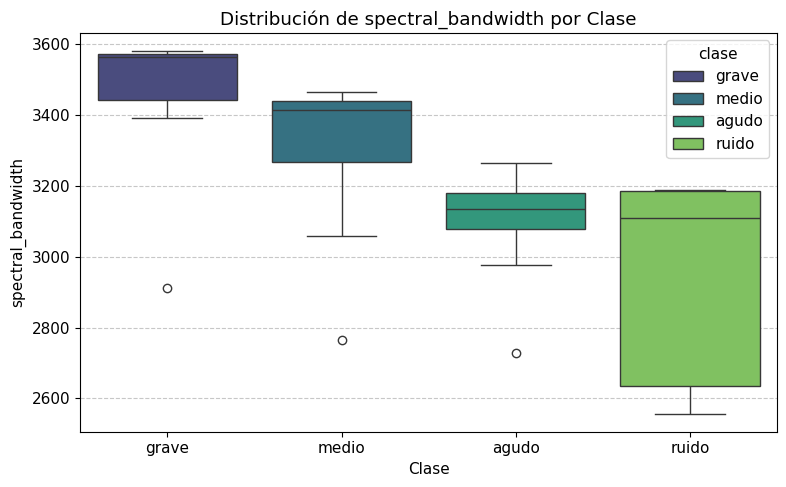

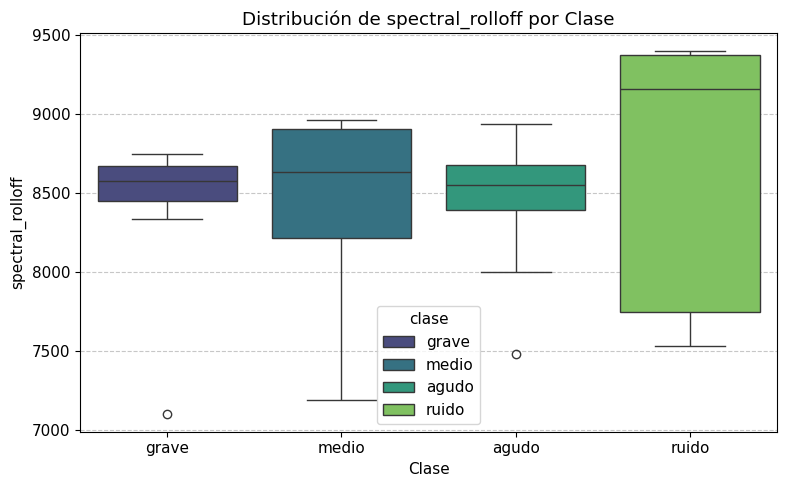

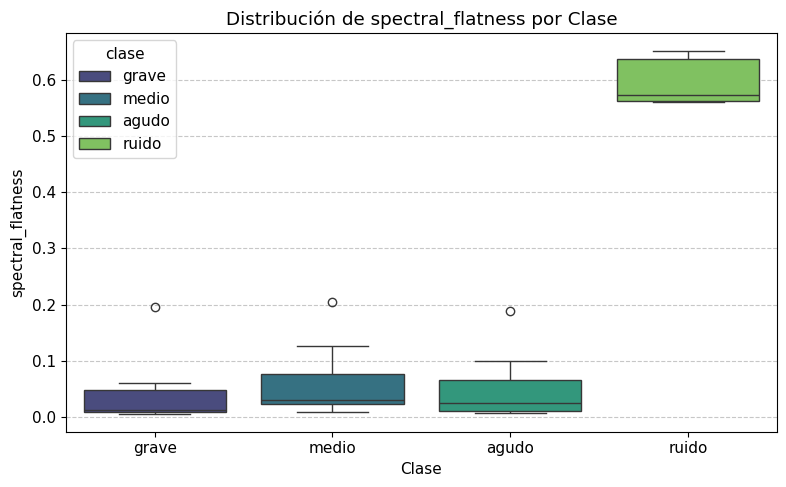


--- Pairplot de Features Clave ---


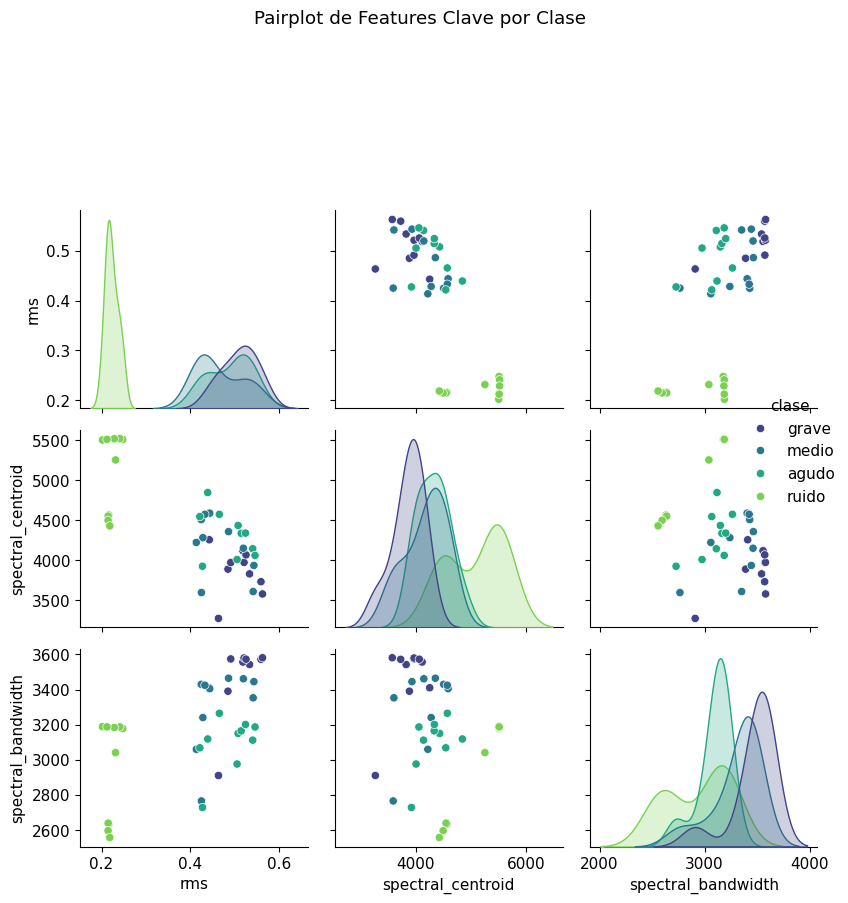


--- Heatmap de Correlación de Features ---


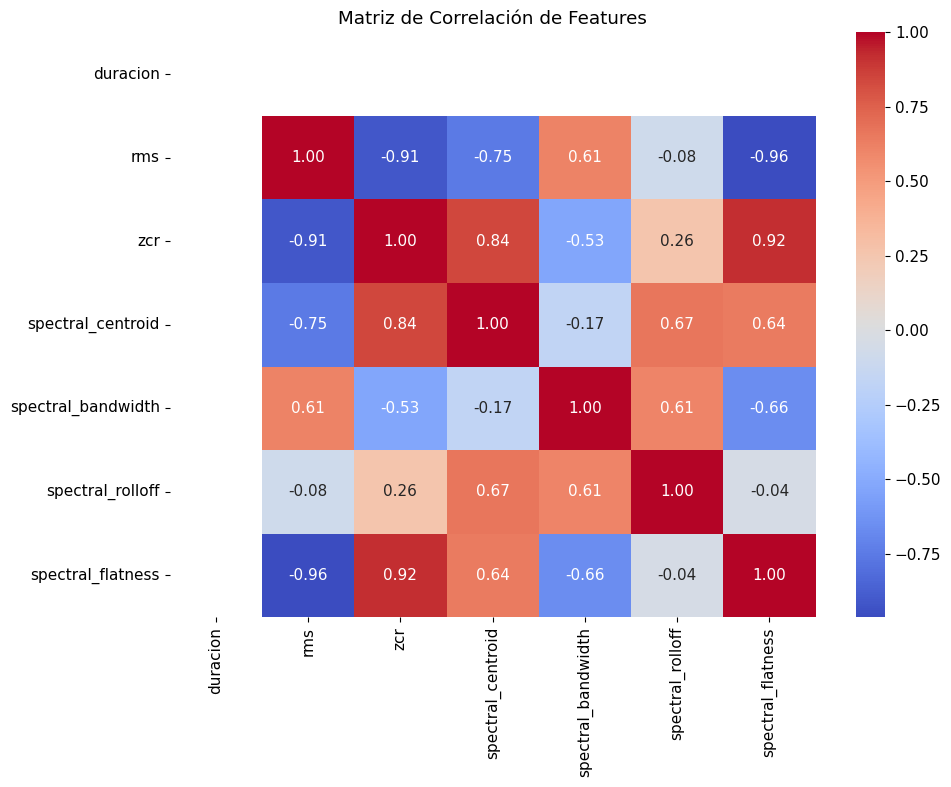


--- Análisis de Correlación Alta ---
Pares de features con correlación absoluta > 0.7:
- zcr y rms: 0.91
- spectral_centroid y rms: 0.75
- spectral_centroid y zcr: 0.84
- spectral_flatness y rms: 0.96
- spectral_flatness y zcr: 0.92

--- Análisis PCA ---


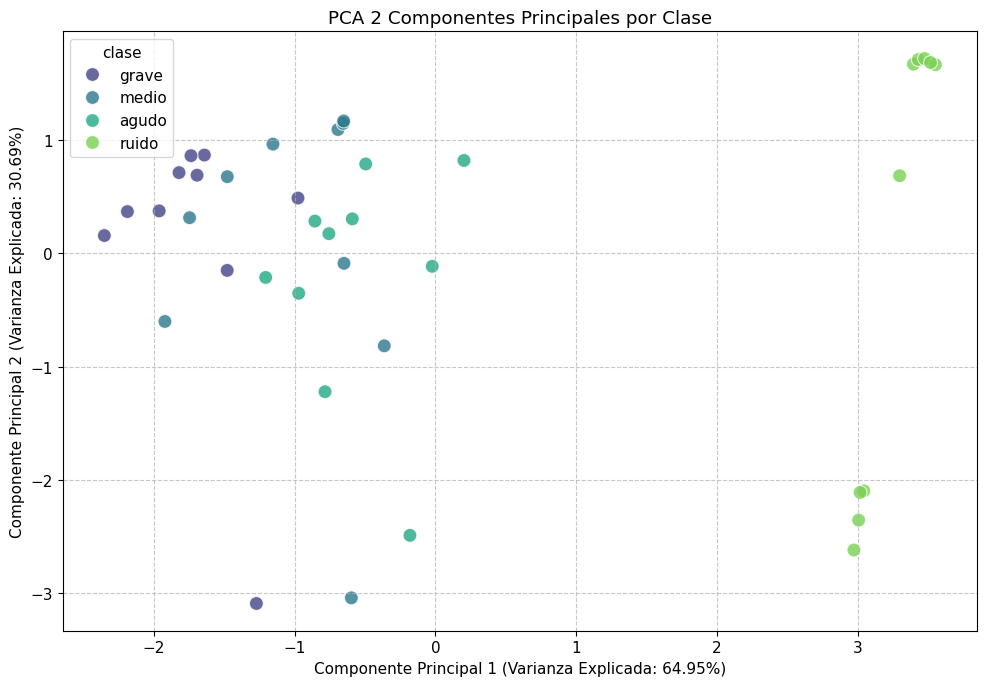

Varianza total explicada por los 2 componentes principales: 95.63%

--- Evaluación de Separabilidad de Clases con PCA ---
Basado en el gráfico PCA, las clases parecen tener cierta separabilidad, especialmente si hay agrupamientos visuales claros.
La varianza explicada (95.63%) es razonablemente alta, lo que indica que estos dos componentes capturan una buena parte de la información discriminativa.


In [13]:
# a) Extraer las siguientes features para cada muestra:
features_lista = []
for muestra in dataset_procesado:
    audio = muestra['audio']
    sr = muestra['sr']
    features = {
        'clase': muestra['clase'],
        'duracion': len(audio) / sr,
        'rms': np.sqrt(np.mean(audio**2)),
        'zcr': librosa.feature.zero_crossing_rate(audio)[0].mean(),
        'spectral_centroid': librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean(),
        'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean(),
        'spectral_rolloff': librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean(),
        'spectral_flatness': librosa.feature.spectral_flatness(y=audio)[0].mean()
    }
    features_lista.append(features)

# Convertir a DataFrame
df_features = pd.DataFrame(features_lista)

print(" Features extraídas y DataFrame creado.")
display(df_features.head())

# b) Estadísticos descriptivos:
# - Calcular media, std, min, max por clase para cada feature
print("\n--- Estadísticas Descriptivas por Clase ---")
df_stats = df_features.groupby('clase').agg(['mean', 'std', 'min', 'max'])
display(df_stats)

# c) Visualizaciones:
# - Boxplot de cada feature comparando las 4 clases
print("\n--- Boxplots de Features por Clase ---")
for feature_name in df_features.columns.drop('clase'):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='clase', y=feature_name, data=df_features, palette='viridis', hue='clase', legend=True)
    #sns.boxplot(x='clase', y=feature_name, data=df_features, palette='viridis')
    plt.title(f'Distribución de {feature_name} por Clase')
    plt.xlabel('Clase')
    plt.ylabel(feature_name)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# - Pairplot de las 3 features más importantes (ej: spectral_centroid, spectral_bandwidth, rms)
print("\n--- Pairplot de Features Clave ---")
# Seleccionamos algunas de las features que parecen más discriminativas de los boxplots
important_features = ['rms', 'spectral_centroid', 'spectral_bandwidth']
sns.pairplot(df_features, vars=important_features, hue='clase', palette='viridis')
plt.suptitle('Pairplot de Features Clave por Clase', y=1.20) # Ajustar el título para que no se solape
plt.tight_layout()
plt.show()

# - Heatmap de correlación de todas las features
print("\n--- Heatmap de Correlación de Features ---")
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.drop('clase', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Features')
plt.tight_layout()
plt.show()

# d) Análisis de correlación:
# - Identificar pares de features con |correlación| > 0.7
print("\n--- Análisis de Correlación Alta ---")
corr_matrix = df_features.drop('clase', axis=1).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_tri.columns for row in upper_tri.index if upper_tri.loc[row, col] > 0.7]

if high_corr_pairs:
    print("Pares de features con correlación absoluta > 0.7:")
    for col1, col2 in high_corr_pairs:
        print(f"- {col1} y {col2}: {corr_matrix.loc[col1, col2]:.2f}")
else:
    print("No se encontraron pares de features con correlación absoluta > 0.7.")

# e) PCA:
# - Aplicar PCA con 2 componentes principales
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n--- Análisis PCA ---")

# Preparar los datos para PCA (escalar y separar características de la clase)
X = df_features.drop('clase', axis=1)
y = df_features['clase']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficar proyección 2D coloreando por clase
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', s=100, alpha=0.8)
plt.title('PCA 2 Componentes Principales por Clase')
plt.xlabel(f'Componente Principal 1 (Varianza Explicada: {pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 (Varianza Explicada: {pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# - Calcular varianza explicada
explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"Varianza total explicada por los 2 componentes principales: {explained_variance:.2f}%")

# - Evaluar si las clases están separables
print("\n--- Evaluación de Separabilidad de Clases con PCA ---")
if explained_variance > 70 and len(set(y)) > 1: # Un umbral arbitrario para buena separabilidad en 2D
    print("Basado en el gráfico PCA, las clases parecen tener cierta separabilidad, especialmente si hay agrupamientos visuales claros.")
    print(f"La varianza explicada ({explained_variance:.2f}%) es razonablemente alta, lo que indica que estos dos componentes capturan una buena parte de la información discriminativa.")
else:
    print("Basado en el gráfico PCA, la separabilidad de las clases no es completamente clara. La varianza explicada podría ser insuficiente para distinguir las clases de forma robusta con solo 2 componentes.")




# Conclusiones sobre la Separabilidad de Clases

A partir del análisis integral de las características extraídas y el comportamiento de los datos, podemos determinar que el dataset presenta una estructura base sólida, aunque con matices importantes para la clasificación. En primer lugar, al observar la matriz de correlación, se hace evidente una dependencia lineal marcada entre variables como spectral_flatness y rms.

Entonces, esto nos indica la presencia de información redundante en el set de datos; por ende, en una etapa posterior de entrenamiento, sería pertinente simplificar el modelo eliminando algunas de estas dimensiones para mejorar la eficiencia computacional sin sacrificar la capacidad explicativa.Por otro lado, con respecto a la capacidad discriminativa de cada métrica, los boxplots revelan que no todas las variables aportan el mismo valor al separar los sonidos. Mientras que el ZCR (Zero Crossing Rate) permite identificar de forma casi inmediata la clase ruido debido a su naturaleza aperiódica, otras métricas como el centroide espectral muestran solapamientos significativos entre las clases agudo, medio y grave.

 En consecuencia, si bien las clases tonales poseen frecuencias fundamentales distintas, sus distribuciones estadísticas globales comparten similitudes que dificultan una distinción lineal simple entre ellas.Finalmente, la validación de este análisis se observa en el gráfico del PCA. Al reducir la dimensionalidad a dos componentes principales, logramos explicar un 95.63% de la varianza total. Sin embargo, la visualización confirma que, si bien el ruido se agrupa en una "isla" totalmente aislada, las clases tonales tienden a mezclarse en un mismo sector del espacio latente.

  En conclusión, aunque las features actuales son excelentes para diferenciar "voz de ruido", presentan limitaciones para desglosar las categorías tonales.